# Classification

## Klasifikační modely v knihovně Scikit-learn

Scikit-learn je jednou z nejpopulárnějších knihoven pro strojové učení v Pythonu. V tomto článku se zaměříme na 5 nejpoužívanějších klasifikačních algoritmů, jejich popis, ukázky kódu, vhodné použití a jejich výhody a nevýhody.

## 1. LogisticRegression

### Popis

LogisticRegression je lineární model používaný pro binární klasifikaci, který může být rozšířen i na vícerozměrnou klasifikaci. Funguje na principu modelování pravděpodobnosti příslušnosti k určité třídě pomocí logistické funkce.

### Kdy a kde použít

- Pro lineárně oddělitelná data
- Když potřebujete interpretovatelný model
- Jako výchozí model pro binární klasifikaci
- Když potřebujete pravděpodobnosti tříd

### Výhody a nevýhody

**Výhody:**
- Rychlý trénink a predikce
- Snadno interpretovatelné koeficienty
- Dobře funguje pro lineárně separovatelná data
- Poskytuje pravděpodobnosti tříd

**Nevýhody:**
- Nezvládá nelineární vztahy bez transformace dat
- Citlivý na odlehlé hodnoty
- Předpokládá nezávislost prediktorů

### Ukázka kódu

Přesnost: 0.9825

Klasifikační report:
              precision    recall  f1-score   support

     maligní       0.97      0.98      0.98        63
     benigní       0.99      0.98      0.99       108

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



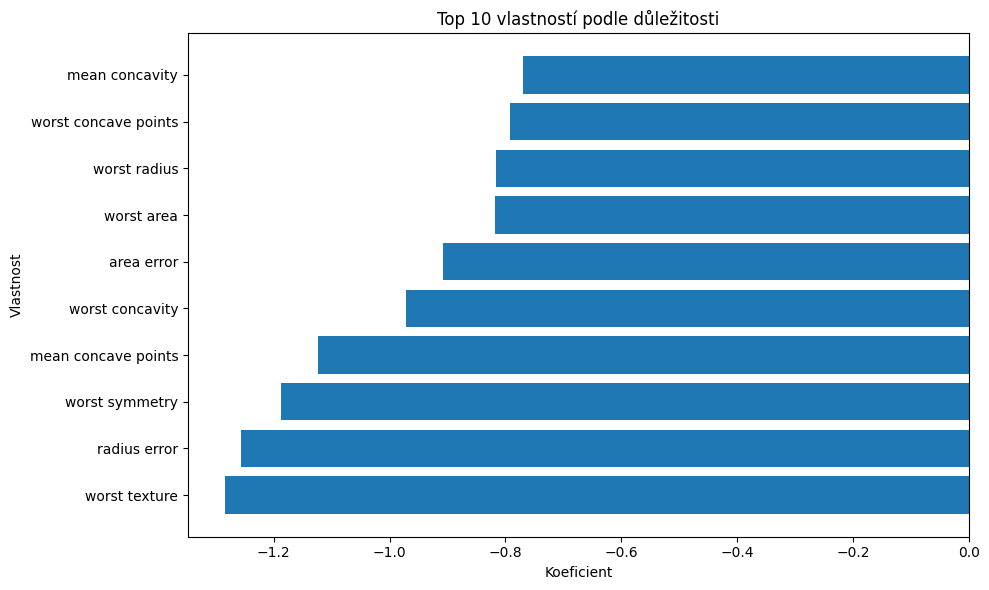

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Načtení datové sady
data = load_breast_cancer()
X, y = data.data, data.target

# Rozdělení dat na trénovací a testovací část
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardizace dat
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Vytvoření a trénink modelu
model = LogisticRegression(C=1.0, solver='liblinear', random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

# Predikce
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Vyhodnocení modelu
print(f"Přesnost: {accuracy_score(y_test, y_pred):.4f}")
print("\nKlasifikační report:")
print(classification_report(y_test, y_pred, target_names=['maligní', 'benigní']))

# Vizualizace koeficientů
coefficients = pd.DataFrame({
    'Feature': data.feature_names,
    'Coefficient': model.coef_[0]
})
top_features = coefficients.reindex(coefficients.Coefficient.abs().sort_values(ascending=False).index)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'][:10], top_features['Coefficient'][:10])
plt.xlabel('Koeficient')
plt.ylabel('Vlastnost')
plt.title('Top 10 vlastností podle důležitosti')
plt.tight_layout()
plt.show()

## 2. RandomForestClassifier

### Popis

RandomForestClassifier je ensemble metoda, která vytváří více rozhodovacích stromů na různých podmnožinách trénovacích dat a používá průměrování k vylepšení přesnosti predikce a kontrole přetrénování.

### Kdy a kde použít

- Pro komplexnější, nelineární vztahy v datech
- Když máte mnoho prediktorů, včetně potenciálně irelevantních
- Když potřebujete robustní model s minimálním laděním hyperparametrů
- Pro vyhodnocení důležitosti jednotlivých vlastností

### Výhody a nevýhody

**Výhody:**
- Robustní vůči přetrénování
- Dobře zvládá nelineární vztahy
- Automaticky vyhodnocuje důležitost vlastností
- Nepotřebuje škálování dat

**Nevýhody:**
- Méně interpretovatelný než jednoduché modely
- Výpočetně náročnější než lineární modely
- Může být pomalý pro velké datasety
- Méně efektivní pro řídká data

### Ukázka kódu

Přesnost: 0.9167

Nejlepší parametry: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Nejlepší skóre: 0.9300
Přesnost nejlepšího modelu: 0.9167


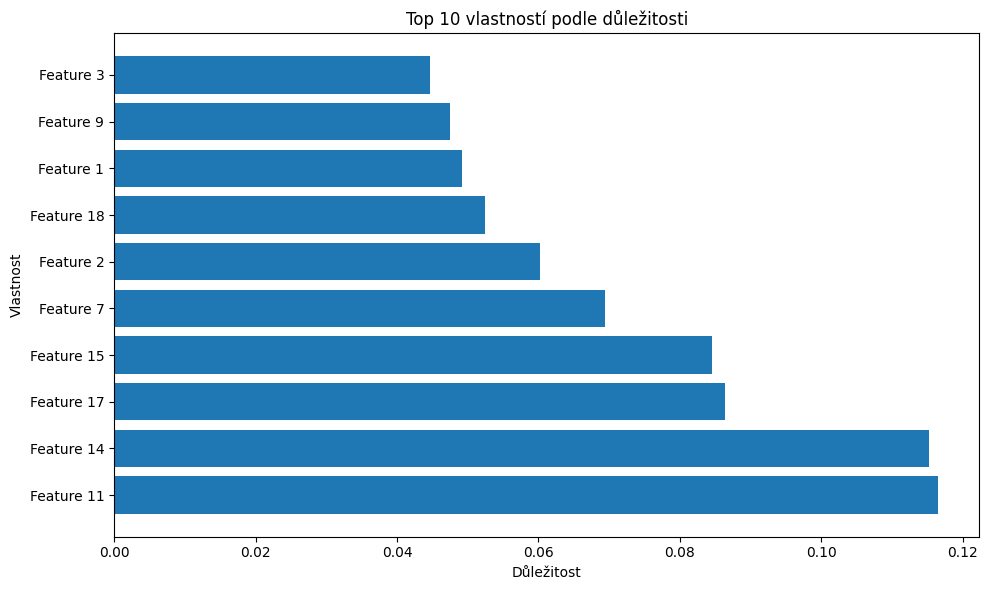

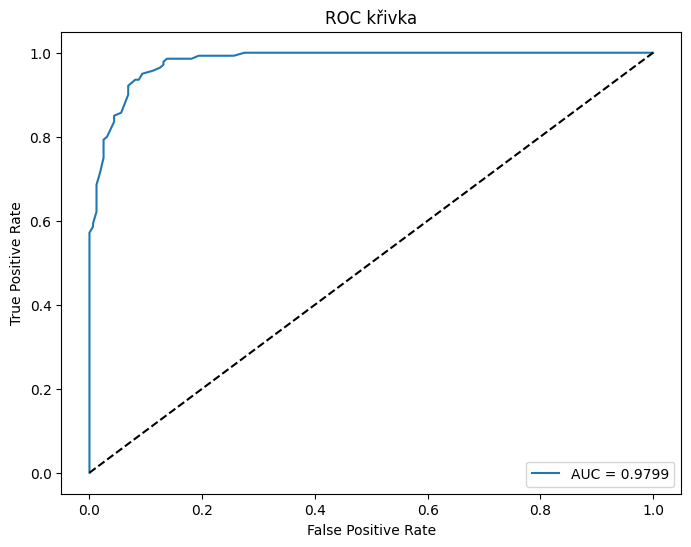

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Vygenerování syntetických dat
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, 
                           n_redundant=5, n_classes=2, random_state=42)

# Rozdělení dat na trénovací a testovací část
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Vytvoření a trénink modelu
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predikce
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

# Vyhodnocení modelu
print(f"Přesnost: {accuracy_score(y_test, y_pred):.4f}")

# Ladění hyperparametrů pomocí GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), 
                          param_grid=param_grid, 
                          cv=3, 
                          scoring='accuracy',
                          n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"\nNejlepší parametry: {grid_search.best_params_}")
print(f"Nejlepší skóre: {grid_search.best_score_:.4f}")

# Použití nejlepšího modelu
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
print(f"Přesnost nejlepšího modelu: {accuracy_score(y_test, y_pred_best):.4f}")

# Důležitost vlastností
feature_importances = pd.DataFrame({
    'Feature': [f'Feature {i}' for i in range(X.shape[1])],
    'Importance': best_rf.feature_importances_
})
feature_importances = feature_importances.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importances['Feature'][:10], feature_importances['Importance'][:10])
plt.xlabel('Důležitost')
plt.ylabel('Vlastnost')
plt.title('Top 10 vlastností podle důležitosti')
plt.tight_layout()
plt.show()

# ROC křivka
fpr, tpr, _ = roc_curve(y_test, best_rf.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC křivka')
plt.legend(loc='lower right')
plt.show()

## 3. SVC (Support Vector Classifier)

### Popis

SVC je implementace algoritmu Support Vector Machine pro klasifikaci. Hledá optimální nadrovinu, která maximalizuje vzdálenost mezi třídami (maximální margin).

### Kdy a kde použít

- Pro data se složitými nelineárními hranicemi
- Pro menší až střední datasety
- Když je důležitá přesnost predikce
- Pro data s vyšší dimenzionalitou

### Výhody a nevýhody

**Výhody:**
- Efektivní ve vysokodimenzionálním prostoru
- Dobře zvládá nelineární klasifikační problémy díky jádrové funkci (kernel trick)
- Robustní proti přetrénování
- Flexibilní díky různým jádrovým funkcím (kernely)

**Nevýhody:**
- Špatně škáluje pro velké datasety (výpočetně náročné)
- Vyžaduje pečlivé ladění hyperparametrů
- Méně interpretovatelný než lineární modely
- Citlivý na škálování dat

### Ukázka kódu

Lineární SVC:
Přesnost: 1.0000

RBF SVC:
Přesnost: 1.0000
Kernel linear: Průměrné skóre křížové validace = 0.9900
Kernel poly: Průměrné skóre křížové validace = 1.0000
Kernel rbf: Průměrné skóre křížové validace = 1.0000
Kernel sigmoid: Průměrné skóre křížové validace = 0.4900


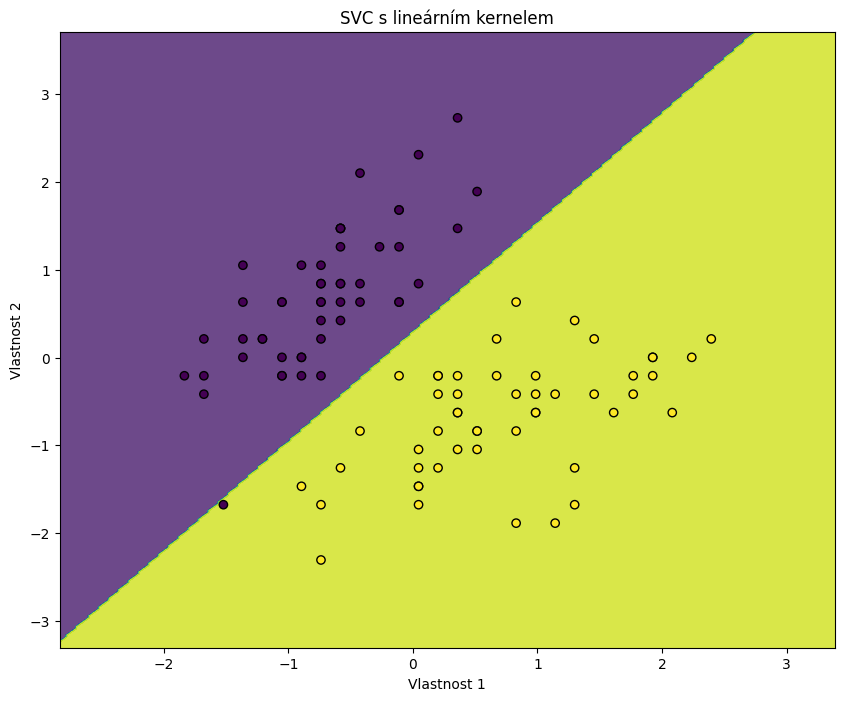

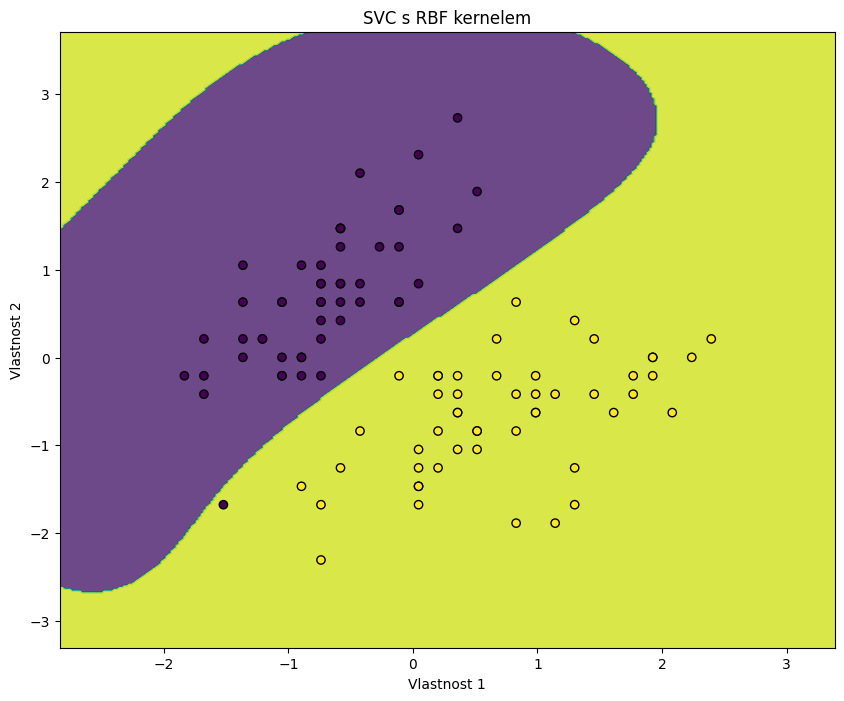

In [3]:
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# Načtení datové sady
iris = load_iris()
X = iris.data
y = iris.target

# Pro vizualizaci budeme používat pouze dvě třídy a dvě vlastnosti
X_binary = X[y != 2][:, :2]  # Pouze první dvě vlastnosti a dvě třídy
y_binary = y[y != 2]

# Rozdělení dat na trénovací a testovací část
X_train, X_test, y_train, y_test = train_test_split(X_binary, y_binary, test_size=0.3, random_state=42)

# Standardizace dat
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Vytvoření a trénink modelu
svc_linear = SVC(kernel='linear', C=1.0, random_state=42)
svc_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

svc_linear.fit(X_train_scaled, y_train)
svc_rbf.fit(X_train_scaled, y_train)

# Predikce
y_pred_linear = svc_linear.predict(X_test_scaled)
y_pred_rbf = svc_rbf.predict(X_test_scaled)

# Vyhodnocení modelu
print("Lineární SVC:")
print(f"Přesnost: {accuracy_score(y_test, y_pred_linear):.4f}")
print("\nRBF SVC:")
print(f"Přesnost: {accuracy_score(y_test, y_pred_rbf):.4f}")

# Porovnání různých kernelů pomocí křížové validace
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
cv_scores = []

for kernel in kernels:
    svc = SVC(kernel=kernel, gamma='scale', random_state=42)
    scores = cross_val_score(svc, X_binary, y_binary, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())
    print(f"Kernel {kernel}: Průměrné skóre křížové validace = {scores.mean():.4f}")

# Vizualizace rozhodovací hranice
def plot_decision_boundary(model, X, y, title):
    h = .02  # krok v síti
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.xlabel('Vlastnost 1')
    plt.ylabel('Vlastnost 2')
    plt.title(title)
    plt.show()

# Škálování celého datasetu pro vizualizaci
X_binary_scaled = scaler.fit_transform(X_binary)

# Vizualizace rozhodovacích hranic
plot_decision_boundary(svc_linear, X_binary_scaled, y_binary, 'SVC s lineárním kernelem')
plot_decision_boundary(svc_rbf, X_binary_scaled, y_binary, 'SVC s RBF kernelem')

## 4. KNeighborsClassifier

### Popis

KNeighborsClassifier implementuje klasifikaci pomocí hlasování k nejbližších sousedů. Třída vzorku je určena většinovým hlasováním jeho k nejbližších sousedů v trénovacích datech.

### Kdy a kde použít

- Pro menší datasety
- Když vztahy mezi daty jsou lokální, nikoliv globální
- Když data mají jasnou strukturu sousedství
- Jako základní (baseline) model pro porovnání s jinými algoritmy

### Výhody a nevýhody

**Výhody:**
- Jednoduchý a intuitivní algoritmus
- Nevyžaduje fázi učení (lazy learner)
- Funguje dobře pro multiclass klasifikaci
- Neparametrický model (nedělá předpoklady o distribuci dat)

**Nevýhody:**
- Pomalý pro velké datasety (výpočetně náročný v době predikce)
- Citlivý na škálování dat
- Citlivý na irelevantní vlastnosti
- Trpí tzv. "prokletím dimenzionality"

### Ukázka kódu

In [4]:
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.datasets import load_wine
# from sklearn.model_selection import train_test_split, GridSearchCV
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import accuracy_score, classification_report
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd
# from sklearn.decomposition import PCA

# # Načtení datové sady
# wine = load_wine()
# X, y = wine.data, wine.target

# # Rozdělení dat na trénovací a testovací část
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# # Standardizace dat
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# # Vytvoření a trénink modelu
# knn = KNeighborsClassifier(n_neighbors=5)
# knn.fit(X_train_scaled, y_train)

# # Predikce
# y_pred = knn.predict(X_test_scaled)

# # Vyhodnocení modelu
# print(f"Přesnost: {accuracy_score(y_test, y_pred):.4f}")
# print("\nKlasifikační report:")
# print(classification_report(y_test, y_pred))

# # Ladění hyperparametru k
# k_values = list(range(1, 31, 2))
# train_scores = []
# test_scores = []

# for k in k_values:
#     knn = KNeighborsClassifier(n_neighbors=k)
#     knn.fit(X_train_scaled, y_train)
#     train_scores.append(knn.score(X_train_scaled, y_train))
#     test_scores.append(knn.score(X_test_scaled, y_test))

# # Vizualizace vlivu parametru k na přesnost
# plt.figure(figsize=(10, 6))
# plt.plot(k_values, train_scores, 'o-', label='Trénovací data')
# plt.plot(k_values, test_scores, 's-', label='Testovací data')
# plt.xlabel('Počet sousedů (k)')
# plt.ylabel('Přesnost')
# plt.title('Vliv počtu sousedů na přesnost klasifikace')
# plt.legend()
# plt.grid(True)
# plt.show()

# # PCA pro vizualizaci dat ve 2D
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_scaled)

# # Vytvoření mřížky pro vizualizaci rozhodovacích hranic
# def plot_decision_boundary_knn(X, y, n_neighbors=5):
#     h = .02  # krok v síti
#     x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
#     y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
#     xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
#                          np.arange(y_min, y_max, h))
    
#     knn = KNeighborsClassifier(n_neighbors=n_neighbors)
#     knn.fit(X, y)
    
#     Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
#     Z = Z.reshape(xx.shape)
    
#     plt.figure(figsize=(10, 8))
#     plt.contourf(xx, yy, Z, alpha=0.8)
#     plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
#     plt.xlabel('PCA komponenta 1')
#     plt.ylabel('PCA komponenta 2')
#     plt.title(f'Rozhodovací hranice KNN (k={n_neighbors})')
#     plt.show()

# # Vizualizace rozhodovací hranice pro různé hodnoty k
# plot_decision_boundary_knn(X_pca, y, n_neighbors=1)
# plot_decision_boundary_knn(X_pca, y, n_neighbors=5)
# plot_decision_boundary_knn(X_pca, y, n_neighbors=15)

```
NameError: name 'X_scaled' is not defined
```

Přesnost: 0.9630

Klasifikační report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      0.90      0.95        21
           2       0.93      1.00      0.97        14

    accuracy                           0.96        54
   macro avg       0.96      0.97      0.96        54
weighted avg       0.97      0.96      0.96        54



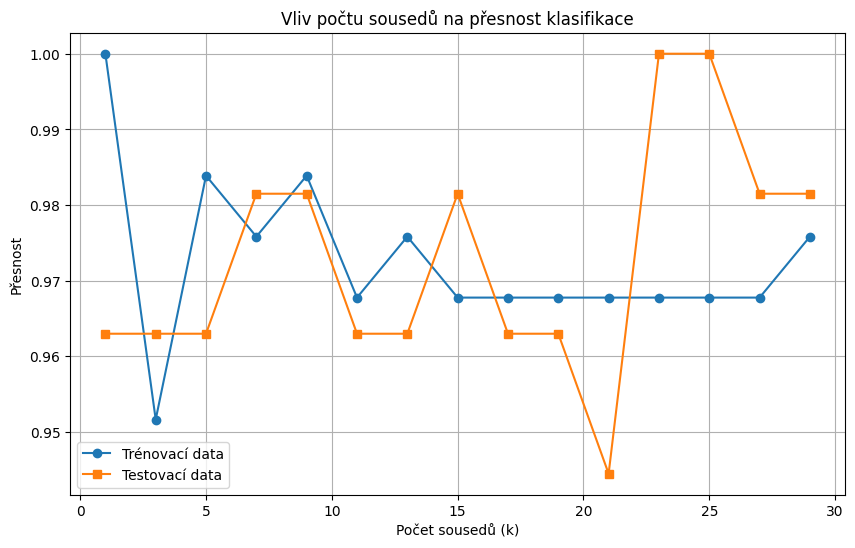

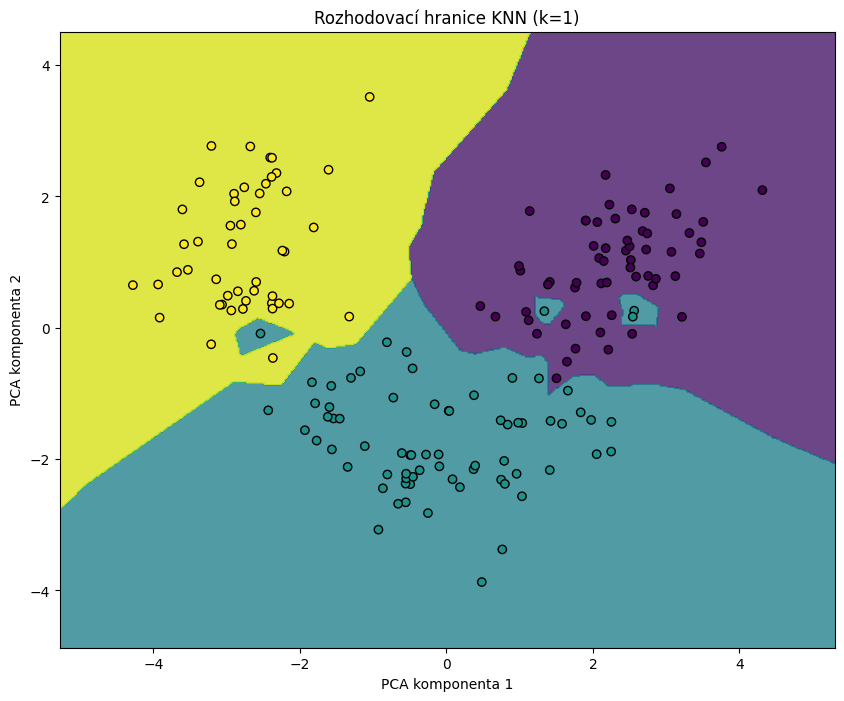

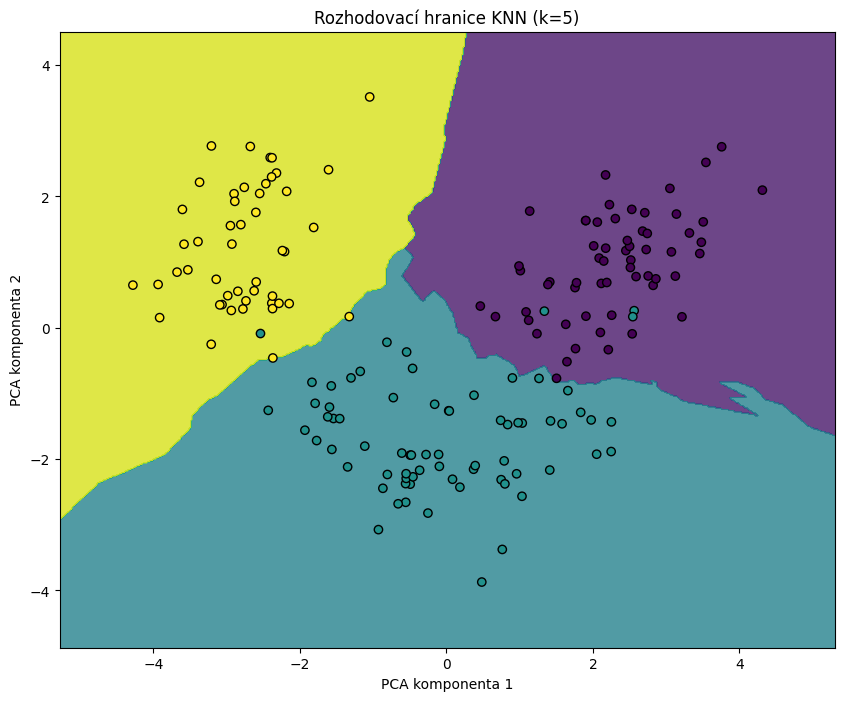

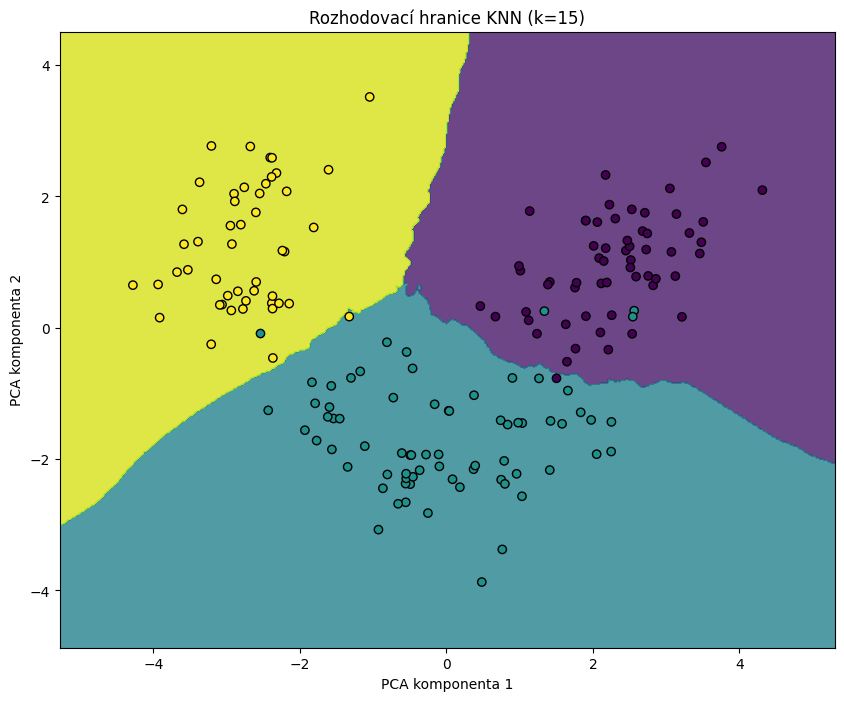

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Načtení datové sady
wine = load_wine()
X, y = wine.data, wine.target

# Rozdělení dat na trénovací a testovací část
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardizace dat
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ❗ Pro PCA vizualizaci musíme standardizovat CELÁ DATA
X_scaled = scaler.fit_transform(X)  # <--- Doplněno

# Vytvoření a trénink modelu
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Predikce
y_pred = knn.predict(X_test_scaled)

# Vyhodnocení modelu
print(f"Přesnost: {accuracy_score(y_test, y_pred):.4f}")
print("\nKlasifikační report:")
print(classification_report(y_test, y_pred))

# Ladění hyperparametru k
k_values = list(range(1, 31, 2))
train_scores = []
test_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_scores.append(knn.score(X_train_scaled, y_train))
    test_scores.append(knn.score(X_test_scaled, y_test))

# Vizualizace vlivu parametru k na přesnost
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, 'o-', label='Trénovací data')
plt.plot(k_values, test_scores, 's-', label='Testovací data')
plt.xlabel('Počet sousedů (k)')
plt.ylabel('Přesnost')
plt.title('Vliv počtu sousedů na přesnost klasifikace')
plt.legend()
plt.grid(True)
plt.show()

# PCA pro vizualizaci dat ve 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)  # ✅ Teď už X_scaled existuje

# Funkce pro vizualizaci rozhodovacích hranic
def plot_decision_boundary_knn(X, y, n_neighbors=5):
    h = .02  # krok v síti
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X, y)
    
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.xlabel('PCA komponenta 1')
    plt.ylabel('PCA komponenta 2')
    plt.title(f'Rozhodovací hranice KNN (k={n_neighbors})')
    plt.show()

# Vizualizace rozhodovacích hranic
plot_decision_boundary_knn(X_pca, y, n_neighbors=1)
plot_decision_boundary_knn(X_pca, y, n_neighbors=5)
plot_decision_boundary_knn(X_pca, y, n_neighbors=15)

## 5. GradientBoostingClassifier

### Popis

GradientBoostingClassifier používá boosting techniku, kde postupně buduje modely na základě chyb předchozích modelů. Typicky používá mělké rozhodovací stromy jako základní modely (weak learners).

### Kdy a kde použít

- Pro komplexní klasifikační problémy
- Když potřebujete vysokou přesnost
- Pro nelineární data
- V soutěžích, kde je důležitá přesnost predikce

### Výhody a nevýhody

**Výhody:**
- Vysoká přesnost predikce
- Robustnost vůči přetrénování díky regularizaci
- Dobře zvládá nelineární vztahy
- Automaticky vyhodnocuje důležitost vlastností

**Nevýhody:**
- Výpočetně náročnější než jednodušší modely
- Obtížnější ladění hyperparametrů
- Méně interpretovatelný
- Sekvenční povaha neumožňuje paralelizaci

### Ukázka kódu

In [6]:
# from sklearn.ensemble import GradientBoostingClassifier
# from sklearn.datasets import load_breast_cancer
# from sklearn.model_selection import train_test_split, RandomizedSearchCV
# from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc
# import matplotlib.pyplot as plt
# import numpy as np
# from scipy.stats import randint, uniform

# # Načtení datové sady
# data = load_breast_cancer()
# X, y = data.data, data.target

# # Rozdělení dat na trénovací a testovací část
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# # Vytvoření a trénink modelu
# gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
# gb.fit(X_train, y_train)

# # Predikce
# y_pred = gb.predict(X_test)
# y_prob = gb.predict_proba(X_test)[:, 1]

# # Vyhodnocení modelu
# print(f"Přesnost: {accuracy_score(y_test, y_pred):.4f}")
# print(f"AUC: {roc_auc_score(y_test, y_prob):.4f}")

# # Randomizované ladění hyperparametrů
# param_dist = {
#     'n_estimators': randint(50, 500),
#     'learning_rate': uniform(0.01, 0.3),
#     'max_depth': randint(2, 10),
#     'min_samples_split': randint(2, 20),
#     'min_samples_leaf': randint(1, 10),
#     'subsample': uniform(0.6, 0.4)
# }

# random_search = RandomizedSearchCV(
#     GradientBoostingClassifier(random_state=42),
#     param_distributions=param_dist,
#     n_iter=20,
#     cv=5,
#     scoring='roc_auc',
#     random_state=42,
#     n_jobs=-1
# )

# random_search.fit(X_train, y_train)

# print(f"\nNejlepší parametry: {random_search.best_params_}")
# print(f"Nejlepší skóre: {random_search.best_score_:.4f}")

# # Použití nejlepšího modelu
# best_gb = random_search.best_estimator_
# y_pred_best = best_gb.predict(X_test)
# y_prob_best = best_gb.predict_proba(X_test)[:, 1]

# print(f"Přesnost nejlepšího modelu: {accuracy_score(y_test, y_pred_best):.4f}")
# print(f"AUC nejlepšího modelu: {roc_auc_score(y_test, y_prob_best):.4f}")

# # Důležitost vlastností
# feature_importances = pd.DataFrame({
#     'Feature': data.feature_names,
#     'Importance': best_gb.feature_importances_
# })
# feature_importances = feature_importances.sort_values('Importance', ascending=False)

# plt.figure(figsize=(10, 6))
# plt.barh(feature_importances['Feature'][:10], feature_importances['Importance'][:10])
# plt.xlabel('Důležitost')
# plt.ylabel('Vlastnost')
# plt.title('Top 10 vlastností podle důležitosti')
# plt.tight_layout()
# plt.show()

# # Vývoj chyby během trénování
# train_scores = np.zeros((best_gb.n_estimators,), dtype=np.float64)
# test_scores = np.zeros((best_gb.n_estimators,), dtype=np.float64)

# for i, y_pred in enumerate(best_gb.staged_predict(X_train)):
#     train_scores[i] = best_gb.loss_(y_train, y_pred)

# for i, y_pred in enumerate(best_gb.staged_predict(X_test)):
#     test_scores[i] = best_gb.loss_(y_test, y_pred)

# plt.figure(figsize=(10, 6))
# plt.plot(np.arange(best_gb.n_estimators) + 1, train_scores, 'b-',
#          label='Trénovací data')
# plt.plot(np.arange(best_gb.n_estimators) + 1, test_scores, 'r-',
#          label='Testovací data')
# plt.legend(loc='upper right')
# plt.xlabel('Počet stromů')
# plt.ylabel('Ztrátová funkce')
# plt.title('Vývoj ztrátové funkce během trénování')
# plt.grid(True)
# plt.show()

# # ROC křivka
# fpr, tpr, _ = roc_curve(y_test, y_prob_best)
# roc_auc = auc(fpr, tpr)

# plt.figure(figsize=(8, 6))
# plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('ROC křivka')
# plt.legend(loc='lower right')
# plt.show()

```
AttributeError: 'GradientBoostingClassifier' object has no attribute 'loss_'
```

Přesnost: 0.9591
AUC: 0.9951

Nejlepší parametry: {'learning_rate': np.float64(0.22319886690573623), 'max_depth': 3, 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 290, 'subsample': np.float64(0.7257423924305306)}
Nejlepší skóre: 0.9912
Přesnost nejlepšího modelu: 0.9708
AUC nejlepšího modelu: 0.9960


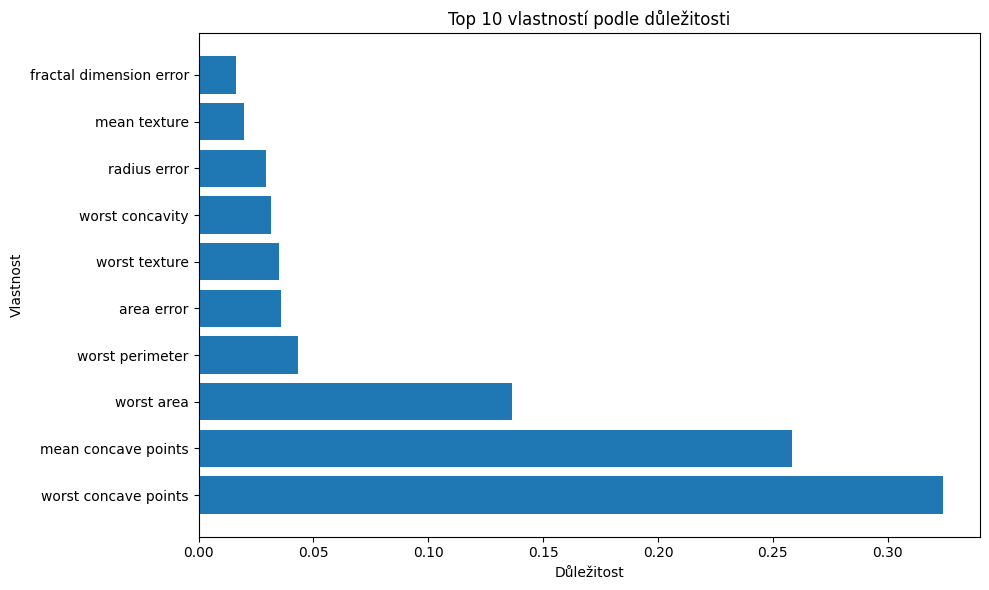

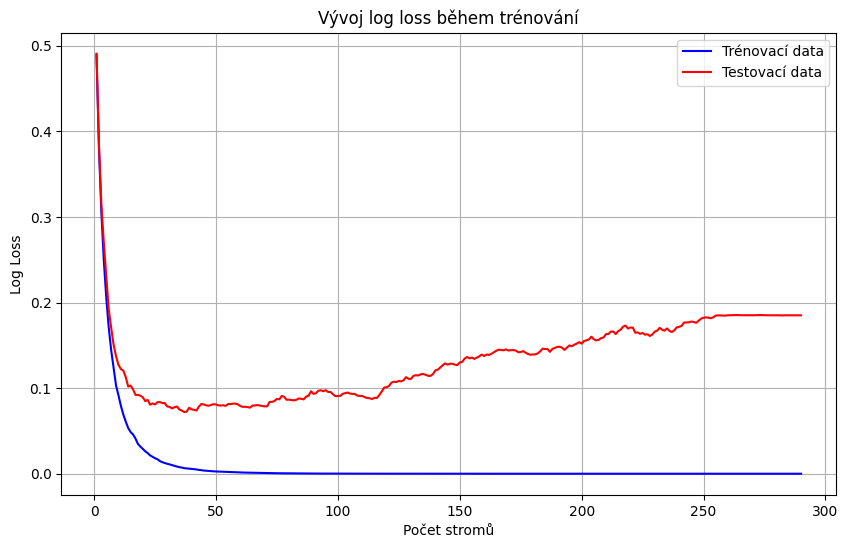

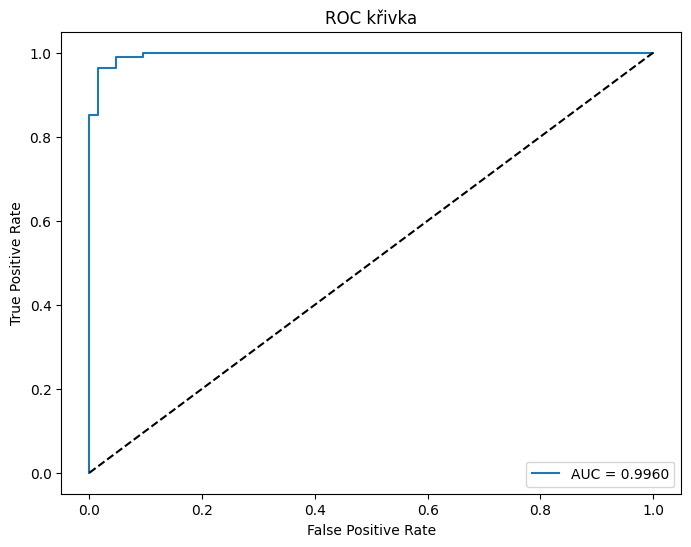

In [7]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc, log_loss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import randint, uniform

# Načtení datové sady
data = load_breast_cancer()
X, y = data.data, data.target

# Rozdělení dat na trénovací a testovací část
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Vytvoření a trénink modelu
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)

# Predikce
y_pred = gb.predict(X_test)
y_prob = gb.predict_proba(X_test)[:, 1]

# Vyhodnocení modelu
print(f"Přesnost: {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_prob):.4f}")

# Randomizované ladění hyperparametrů
param_dist = {
    'n_estimators': randint(50, 500),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(2, 10),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'subsample': uniform(0.6, 0.4)
}

random_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print(f"\nNejlepší parametry: {random_search.best_params_}")
print(f"Nejlepší skóre: {random_search.best_score_:.4f}")

# Použití nejlepšího modelu
best_gb = random_search.best_estimator_
y_pred_best = best_gb.predict(X_test)
y_prob_best = best_gb.predict_proba(X_test)[:, 1]

print(f"Přesnost nejlepšího modelu: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"AUC nejlepšího modelu: {roc_auc_score(y_test, y_prob_best):.4f}")

# Důležitost vlastností
feature_importances = pd.DataFrame({
    'Feature': data.feature_names,
    'Importance': best_gb.feature_importances_
})
feature_importances = feature_importances.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importances['Feature'][:10], feature_importances['Importance'][:10])
plt.xlabel('Důležitost')
plt.ylabel('Vlastnost')
plt.title('Top 10 vlastností podle důležitosti')
plt.tight_layout()
plt.show()

# Vývoj log loss během tréninku
train_scores = np.zeros((best_gb.n_estimators,), dtype=np.float64)
test_scores = np.zeros((best_gb.n_estimators,), dtype=np.float64)

# Log loss na základě staged_predict_proba (po každém stromu)
for i, y_prob in enumerate(best_gb.staged_predict_proba(X_train)):
    train_scores[i] = log_loss(y_train, y_prob)

for i, y_prob in enumerate(best_gb.staged_predict_proba(X_test)):
    test_scores[i] = log_loss(y_test, y_prob)

plt.figure(figsize=(10, 6))
plt.plot(np.arange(best_gb.n_estimators) + 1, train_scores, 'b-',
         label='Trénovací data')
plt.plot(np.arange(best_gb.n_estimators) + 1, test_scores, 'r-',
         label='Testovací data')
plt.legend(loc='upper right')
plt.xlabel('Počet stromů')
plt.ylabel('Log Loss')
plt.title('Vývoj log loss během trénování')
plt.grid(True)
plt.show()

# ROC křivka
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC křivka')
plt.legend(loc='lower right')
plt.show()

## Srovnávací tabulka klasifikátorů

| Klasifikátor | Rychlost trénování | Rychlost predikce | Interpretovatelnost | Nelineární vztahy | Vysokodim. data | Potřeba škálování | Hyperparametry | Hlavní výhody | Hlavní nevýhody |
|--------------|-------------------|------------------|---------------------|-------------------|-----------------|-------------------|----------------|--------------|----------------|
| LogisticRegression | Rychlé | Rychlé | Vysoká | Ne | Průměrné | Ano | Méně | Rychlost, interpretace | Pouze lineární vztahy |
| RandomForestClassifier | Střední | Střední | Střední | Ano | Dobré | Ne | Středně | Robustnost, přesnost | Výpočetní náročnost |
| SVC | Pomalé | Střední | Nízká | Ano | Velmi dobré | Ano | Více | Přesnost, regularizace | Výpočetní náročnost |
| KNeighborsClassifier | Velmi rychlé | Pomalé | Střední | Ano | Špatné | Ano | Málo | Jednoduchý, intuitivní | Pomalá predikce, "prokletí dimenzionality" |
| GradientBoostingClassifier | Pomalé | Střední | Nízká | Ano | Dobré | Ne | Mnoho | Vysoká přesnost | Komplexnost, ladění parametrů |